In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Hyperparameters
n_points = 500
n_steps = 300
beta_start = 0.0001
beta_end = 0.02
device = torch.device("cpu") # or "cuda" 

# --- 1. Generate Spiral Data ---
theta = np.linspace(0, 4 * np.pi, n_points)
radius = theta
x = radius * np.cos(theta)
y = radius * np.sin(theta)

# Labels: 1 (Red), 2 (Green), 3 (Blue) so deviding it in 3
labels = np.zeros(n_points, dtype=int)
labels[:n_points//3] = 1
labels[n_points//3:2*n_points//3] = 2
labels[2*n_points//3:n_points] = 3

# Normalize coordinates to [-1, 1] for better NN stability , not necessary in this case 
coords = np.column_stack((x, y))
#coords = (coords - coords.min()) / (coords.max() - coords.min()) * 2 - 1

# Convert to Tensors
x0 = torch.tensor(coords, dtype=torch.float32).to(device)
color_labels = torch.tensor(labels, dtype=torch.long).to(device)

# --- 2. Define Manual Noise Schedule (The DDIM/DDPM Math) ---
betas = torch.linspace(beta_start, beta_end, n_steps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

def q_sample(x_0, t, noise=None):
    if noise is None:
        # Create noise on the same device as x_0
        noise = torch.randn_like(x_0)
    
    # Ensure t is used to index alphas_cumprod on the same device
    sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t]).view(-1, 1)
    sqrt_one_minus_alpha_cumprod = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1)
    
    return sqrt_alpha_cumprod * x_0 + sqrt_one_minus_alpha_cumprod * noise

In [55]:
class ConditionalDenoiser(nn.Module):
    def __init__(self, n_steps):
        super().__init__()
        # Time Embedding: 200 steps -> 4D vector
        self.time_embed = nn.Embedding(n_steps, 16)
        # Color Embedding: 4 indices (0,1,2,3) -> 4D vector
        self.color_embed = nn.Embedding(4, 16)
        
        self.net = nn.Sequential(
            nn.Linear(2 + 16 + 16, 64), # 2(coords) + 4(time) + 4(color)
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 4),
            nn.LeakyReLU(),
            nn.Linear(4, 2) # Output: Predicted Noise (epsilon)
        )

    def forward(self, x_t, t, c):
        t_f = self.time_embed(t)
        c_f = self.color_embed(c)
        combined = torch.cat([x_t, t_f, c_f], dim=-1)
        return self.net(combined)

model = ConditionalDenoiser(n_steps).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [56]:
epochs = 10000
   

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Pick random timesteps for each point in the batch
    t = torch.randint(0, n_steps, (n_points,), device=device)
 
    # Add noise
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
       
    # Predict the noise
    predicted_noise = model(xt, t, color_labels)
    
    # Loss: How well did we guess the epsilon?
    loss = criterion(predicted_noise, noise)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 1.060489
Epoch 500 | Loss: 0.908431
Epoch 1000 | Loss: 0.672913
Epoch 1500 | Loss: 0.536742
Epoch 2000 | Loss: 0.579024
Epoch 2500 | Loss: 0.527549
Epoch 3000 | Loss: 0.539561
Epoch 3500 | Loss: 0.494925
Epoch 4000 | Loss: 0.499588
Epoch 4500 | Loss: 0.556801
Epoch 5000 | Loss: 0.523559
Epoch 5500 | Loss: 0.490193
Epoch 6000 | Loss: 0.490536
Epoch 6500 | Loss: 0.471300
Epoch 7000 | Loss: 0.476987
Epoch 7500 | Loss: 0.508762
Epoch 8000 | Loss: 0.500838
Epoch 8500 | Loss: 0.540522
Epoch 9000 | Loss: 0.515910
Epoch 9500 | Loss: 0.476516


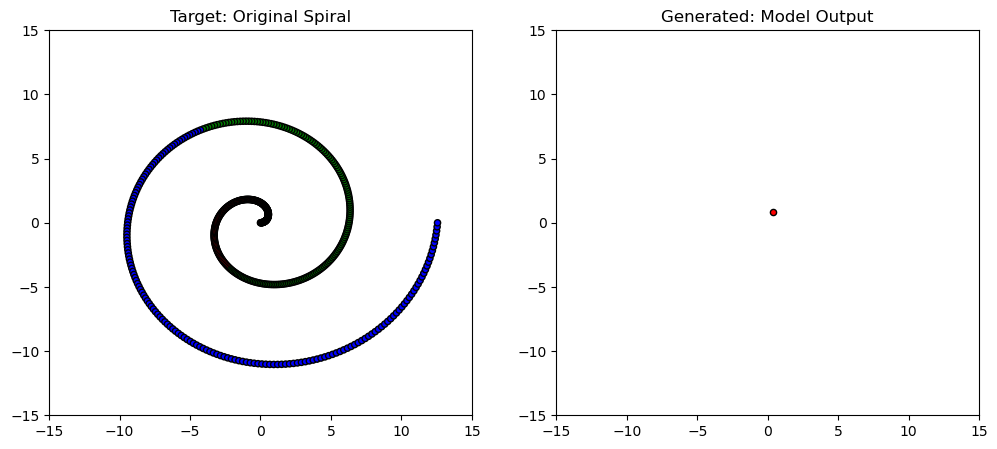

In [59]:
@torch.no_grad()
def sample_spiral(ng_points,colornumber):
    model.eval()
    # Start from pure Gaussian noise
    x_gen = torch.randn(ng_points, 2).to(device)
    
    
    #visualizatiopn
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    c_map = {1: 'red', 2: 'green', 3: 'blue'}
    
    # Iterate backwards from T to 0
    for i in reversed(range(n_steps)):
        t_idx = torch.full((ng_points,), i, dtype=torch.long, device=device)
        gcolor_labels = torch.full((ng_points,), colornumber, dtype=torch.long, device=device)
        
        # 1. Predict noise
        eps_theta = model(x_gen, t_idx, gcolor_labels)
        
        # 2. Compute coefficients
        alpha_t = alphas[i]
        alpha_t_bar = alphas_cumprod[i]
        beta_t = betas[i]
        
        # 3. Denoisestep (Simplified DDPM)
        mean = (1 / torch.sqrt(alpha_t)) * (x_gen - ((1 - alpha_t) / torch.sqrt(1 - alpha_t_bar)) * eps_theta)
        
        if i > 0:  # use i<0 if you want to see the effect without adding noise
            noise = torch.randn_like(x_gen)
            x_gen = mean + torch.sqrt(beta_t) * noise
        else:
            x_gen = mean

        generated_coords=x_gen.cpu().numpy()
        gcolor_labels=gcolor_labels.cpu().numpy()
        
        colors = [c_map[l] for l in labels]
        gcolor = [c_map[l] for l in gcolor_labels]

        # 1. Clear previous drawings
        ax[0].cla()
        ax[1].cla()

        #start plotting
        ax[0].scatter(coords[:, 0], coords[:, 1], c=colors, edgecolors='k',s=20)
        ax[0].set_title("Target: Original Spiral")
        ax[0].set_xlim([-15, 15]) # Set fixed limits so the plot doesn't "jump"
        ax[0].set_ylim([-15, 15])
        
        ax[1].scatter(generated_coords[:, 0], generated_coords[:, 1], c=gcolor, edgecolors='k',s=20)
        ax[1].set_title("Generated: Model Output")
        ax[1].set_xlim([-15, 15]) # Set fixed limits so the plot doesn't "jump"
        ax[1].set_ylim([-15, 15])
        
        display.display(plt.gcf())
        display.clear_output(wait=True)
            
    return x_gen.cpu().numpy(),gcolor_labels

# Test the model
#fist input is number of samples to generate
#second input is color class 1,2,3
generated_coords,gcolor_labels = sample_spiral(50,2)
